## Initialization

In [1]:
import os
import pandas as pd

# This is where Kaggle stores any data you add to your notebook
base_path = '/kaggle/input/datasets/prishabhkumar/adni-dataset'  # ← Replace with your actual dataset name
csv_file_name = 'DXSUM_15Apr2026.csv'
csv_path = os.path.join(base_path, csv_file_name)

print(f"Checking access to target file: {csv_path}")
if os.path.exists(csv_path):
    print("File found...")
else:
    print("Not found")

Checking access to target file: /kaggle/input/datasets/prishabhkumar/adni-dataset/DXSUM_15Apr2026.csv
File found...


## Participant selection
Here, we are seelcting 100 participants (50 normal and 50 with AD) based on only their first visit (baseline) so that we test everyone on the same level.

In [2]:
# Open and read the data file
df = pd.read_csv(csv_path, low_memory=False)

# Clean up any accidental spaces in the data
df['PTID'] = df['PTID'].str.strip()
df['VISCODE2'] = df['VISCODE2'].str.strip()

# Keep only records from each person's very first visit
baseline_mask = df['VISCODE2'] == 'bl'
baseline_df = df[baseline_mask].copy()

# Separate the two groups:
# 1 = Healthy (CN), 3 = Alzheimer's (AD)
cn_cohort = baseline_df[baseline_df['DIAGNOSIS'] == 1]['PTID'].unique()
ad_cohort = baseline_df[baseline_df['DIAGNOSIS'] == 3]['PTID'].unique()

print(f"Findings : ")
print(f" -> Healthy participants: {len(cn_cohort)}")
print(f" -> Alzheimer's participants: {len(ad_cohort)}")

# Pick 50 people from each group
selected_cn = list(cn_cohort[:50])
selected_ad = list(ad_cohort[:50])
target_subjects = selected_cn + selected_ad

# Combine all their IDs into one list, separated by commas
loni_search_string = ",".join(target_subjects)

print("\nThis is the list of patient IDs that can now directly be pasted into the ADNI search portal : ")
print(loni_search_string)

Findings : 
 -> Healthy participants: 1202
 -> Alzheimer's participants: 462

This is the list of patient IDs that can now directly be pasted into the ADNI search portal : 
011_S_0002,011_S_0005,011_S_0008,100_S_0015,023_S_0031,011_S_0016,011_S_0021,011_S_0022,022_S_0014,100_S_0035,022_S_0066,067_S_0019,023_S_0058,007_S_0068,023_S_0061,100_S_0047,035_S_0048,067_S_0056,099_S_0040,011_S_0023,027_S_0074,067_S_0059,100_S_0069,010_S_0067,032_S_0095,018_S_0055,123_S_0072,023_S_0081,123_S_0106,022_S_0096,018_S_0043,022_S_0130,099_S_0090,007_S_0070,131_S_0123,027_S_0120,098_S_0171,041_S_0125,114_S_0166,114_S_0173,035_S_0156,073_S_0089,068_S_0210,068_S_0127,021_S_0159,136_S_0186,027_S_0118,020_S_0097,123_S_0113,136_S_0184,011_S_0003,022_S_0007,067_S_0029,011_S_0010,011_S_0053,123_S_0091,123_S_0094,023_S_0078,067_S_0076,023_S_0084,023_S_0093,023_S_0083,068_S_0109,023_S_0139,098_S_0149,022_S_0129,123_S_0088,032_S_0147,114_S_0228,067_S_0110,123_S_0162,128_S_0167,005_S_0221,022_S_0219,128_S_0216,01

### Code to check the side, front and top view of the scans to ensure everything is correct

In [3]:
# code to install the libraries
!pip install pydicom numpy matplotlib

✅ Full Scan Found: /kaggle/input/datasets/prishabhkumar/adni-clean-baseline-t1/Project Initial data/ADNI/128_S_0266/MP-RAGE/2006-03-22_10_19_35.0/I12294
📐 Sorting along axis 0 (varies by 214.80mm)


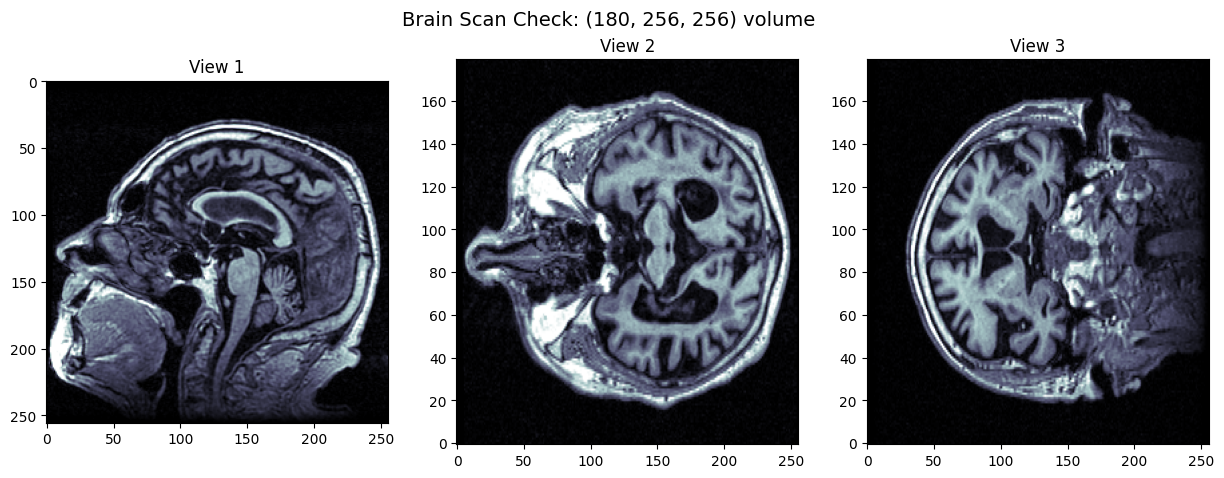

In [4]:
import os
import glob
import pydicom
import numpy as np
import matplotlib.pyplot as plt

# --- AUTO-SORTING BRAIN SEARCH ---
all_dcm = glob.glob('/kaggle/input/**/*.dcm', recursive=True)
candidate_dirs = {d: len(glob.glob(os.path.join(d, '*.dcm'))) for d in set(os.path.dirname(f) for f in all_dcm)}
brain_dir = max(candidate_dirs, key=candidate_dirs.get) if candidate_dirs else None

if brain_dir:
    print(f"✅ Full Scan Found: {brain_dir}")
    
    # Load all slices
    slices = [pydicom.dcmread(os.path.join(brain_dir, f)) for f in os.listdir(brain_dir) if f.endswith('.dcm')]
    
    # --- AUTO-DETECT SORTING AXIS ---
    # We look at the 'ImagePositionPatient' and find which of the 3 coordinates varies the most
    positions = np.array([s.ImagePositionPatient for s in slices])
    diffs = np.max(positions, axis=0) - np.min(positions, axis=0)
    sorting_axis = np.argmax(diffs) # 0 for X, 1 for Y, 2 for Z
    
    print(f"📐 Sorting along axis {sorting_axis} (varies by {diffs[sorting_axis]:.2f}mm)")
    slices.sort(key=lambda x: float(x.ImagePositionPatient[sorting_axis]))
    
    # Stack the pixels
    data = np.stack([s.pixel_array for s in slices])

    # --- AUTO-BRIGHTNESS (Windowing) ---
    # This ignores the darkest 10% and brightest 1% to make the brain visible
    vmin = np.percentile(data, 10)
    vmax = np.percentile(data, 99)

    # Show three views
    z, y, x = data.shape
    mid_z, mid_y, mid_x = z // 2, y // 2, x // 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(data[mid_z, :, :], cmap='bone', vmin=vmin, vmax=vmax)
    axes[0].set_title("View 1")
    axes[1].imshow(data[:, mid_y, :], cmap='bone', aspect='auto', origin='lower', vmin=vmin, vmax=vmax)
    axes[1].set_title("View 2")
    axes[2].imshow(data[:, :, mid_x], cmap='bone', aspect='auto', origin='lower', vmin=vmin, vmax=vmax)
    axes[2].set_title("View 3")
    
    plt.suptitle(f"Brain Scan Check: {data.shape} volume", fontsize=14)
    plt.show()
else:
    print("❌ No scan folder found.")
